# Hyperparameter Tuning with Weights & Biases

Use a **W&B Bayesian sweep** to tune learning rate, regularization, and model size for the TinyShakespeare character-level GPT.

## Prerequisites

- Run `2. Preprocessing.ipynb` first to populate `data/artifacts/`.
- Optional: review `3. Baseline Model Architecture.ipynb` for the base GPT design.
- Install and authenticate W&B: `pip install wandb` then `wandb login`.

## Workflow

| Step | Section | What happens |
|------|---------|--------------|
| 1 | Setup | Import dependencies, resolve paths, define `BASE_CONFIG` |
| 2 | Load data | Load tokenized train/val splits and define batch sampling |
| 3 | Model | Build decoder-only GPT (same architecture family as baseline) |
| 4 | Training | Create optimizer/scheduler and run `train()` with W&B logging |
| 5 | Sweep config | Define the Bayesian search space |
| 6 | Launch | Create a sweep and run `wandb.agent()` |
| 7 | Results | Rank runs and inspect sensitivity plots |

Each trial logs training/validation metrics, tracks the best `val/loss`, and saves a run-specific checkpoint artifact.


## Setup

Import dependencies, resolve the project root, and define `BASE_CONFIG`.

`BASE_CONFIG` contains fallback defaults for any hyperparameter not explicitly sampled by the sweep. Inside `train()`, values from `wandb.config` are merged on top of these defaults.


In [1]:
from pathlib import Path
import random
import time
import math
import json

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import wandb
except ImportError as e:
    raise ImportError("Install wandb: pip install wandb") from e

cwd = Path.cwd()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(f"Could not locate a 'data' directory from cwd: {cwd}")

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = DATA_DIR / "artifacts"

BASE_CONFIG = {
    "seed": 42,
    "block_size": 128,
    "batch_size": 32,
    "max_steps": 2000,
    "eval_interval": 200,
    "learning_rate": 3e-4,
    "weight_decay": 0.1,
    "betas": (0.9, 0.95),
    "warmup_steps": 100,
    "min_lr": 1e-5,
    "n_layers": 4,
    "d_model": 128,
    "n_heads": 4,
    "d_ff": 4,
    "dropout": 0.2,
    "wandb_project": "genre-story-generator",
    "wandb_entity": None,
    "wandb_group": "sweep_lr_dropout",
    "wandb_job_type": "training-sweep",
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
set_seed(BASE_CONFIG["seed"])


Using device: cuda


## Load Artifacts

Load preprocessed token IDs generated in notebook 2. The `get_batch` helper returns:

- **x**: input token windows with shape `(batch_size, block_size)`
- **y**: next-token targets shifted by one position


In [2]:
train_ids_path = ARTIFACTS_DIR / "train_ids.pt"
val_ids_path = ARTIFACTS_DIR / "val_ids.pt"
vocab_path = ARTIFACTS_DIR / "char_vocab.json"

assert train_ids_path.exists(), f"Missing {train_ids_path}. Run preprocessing notebook first."
assert val_ids_path.exists(), f"Missing {val_ids_path}. Run preprocessing notebook first."
assert vocab_path.exists(), f"Missing {vocab_path}. Run preprocessing notebook first."

train_ids = torch.load(train_ids_path)
val_ids = torch.load(val_ids_path)

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab_payload = json.load(f)

vocab_size = vocab_payload["vocab_size"]
print("train_ids:", train_ids.shape, "| val_ids:", val_ids.shape, "| vocab:", vocab_size)


def get_batch(split: str, batch_size: int, block_size: int, device: str = device):
    if split == "train":
        data = train_ids
    elif split == "val":
        data = val_ids
    else:
        raise ValueError("split must be 'train' or 'val'")

    if len(data) <= block_size:
        raise ValueError(f"{split} split too short for block_size={block_size}")

    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i : i + block_size] for i in ix])
    y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


train_ids: torch.Size([1003854]) | val_ids: torch.Size([55770]) | vocab: 65


## Model Architecture

Compact **decoder-only GPT** (same design family as notebook 3):

`tokens -> embeddings -> N x Transformer blocks -> LayerNorm -> linear head`

Sweep-tuned fields: `n_layers`, `d_model`, `n_heads`, and `dropout`.


In [3]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        self.register_buffer("mask", None, persistent=False)

    def _causal_mask(self, size: int, device: torch.device):
        if self.mask is None or self.mask.size(0) < size:
            mask = torch.tril(torch.ones(size, size, device=device)).view(1, 1, size, size)
            self.mask = mask
        return self.mask[:, :, :size, :size]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.size()
        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        def reshape_heads(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q = reshape_heads(q)
        k = reshape_heads(k)
        v = reshape_heads(v)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = self._causal_mask(T, x.device)
        att = att.masked_fill(mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.out_proj(y))
        return y


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff_mult: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff_mult * d_model),
            nn.GELU(),
            nn.Linear(d_ff_mult * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size: int, config: dict):
        super().__init__()
        d_model = config["d_model"]
        n_heads = config["n_heads"]
        n_layers = config["n_layers"]
        dropout = config["dropout"]
        block_size = config["block_size"]
        d_ff_mult = config.get("d_ff", 4)

        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, d_ff_mult, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor | None = None):
        B, T = idx.size()
        if T > self.block_size:
            raise ValueError(f"Sequence length {T} exceeds block_size {self.block_size}")

        pos = torch.arange(0, T, device=idx.device, dtype=torch.long).unsqueeze(0)
        tok_emb = self.token_embedding(idx)
        pos_emb = self.pos_embedding(pos)
        x = self.drop(tok_emb + pos_emb)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)
        return logits, loss


## Learning Rate Schedule

Use **linear warmup followed by cosine decay** down to `min_lr`. This is a common schedule for transformer training, and `warmup_steps` is included in the sweep.


In [4]:
class CosineWarmupScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_steps: int, max_steps: int, min_lr: float = 0.0, last_epoch: int = -1):
        self.warmup_steps = warmup_steps
        self.max_steps = max_steps
        self.min_lr = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch + 1
        if step < self.warmup_steps:
            scale = step / max(1, self.warmup_steps)
        else:
            progress = (step - self.warmup_steps) / max(1, self.max_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            scale = 0.5 * (1.0 + math.cos(math.pi * progress))
        return [self.min_lr + (base_lr - self.min_lr) * scale for base_lr in self.base_lrs]


## Training Loop

| Function | Role |
|----------|------|
| `create_model_and_optimizer` | Build GPT and AdamW (decoupled weight decay) |
| `evaluate_loss` | Compute mean validation cross-entropy |
| `train` | W&B sweep callback that logs metrics and saves the best checkpoint |

**Important:** `train()` merges sampled values from `wandb.config` over `BASE_CONFIG` *after* `wandb.init()`, so each trial runs with its assigned hyperparameters.


In [5]:
def create_model_and_optimizer(config: dict):
    model = GPTLanguageModel(vocab_size=vocab_size, config=config).to(device)

    decay_params, no_decay_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.dim() >= 2 and "bias" not in name and "norm" not in name.lower():
            decay_params.append(p)
        else:
            no_decay_params.append(p)

    optim_groups = [
        {"params": decay_params, "weight_decay": config["weight_decay"]},
        {"params": no_decay_params, "weight_decay": 0.0},
    ]

    optimizer = torch.optim.AdamW(
        optim_groups,
        lr=config["learning_rate"],
        betas=config.get("betas", (0.9, 0.95)),
    )

    scheduler = CosineWarmupScheduler(
        optimizer,
        warmup_steps=config["warmup_steps"],
        max_steps=config["max_steps"],
        min_lr=config.get("min_lr", 0.0),
    )

    return model, optimizer, scheduler


@torch.no_grad()
def evaluate_loss(model: nn.Module, config: dict, num_batches: int = 50):
    model.eval()
    losses = []
    for _ in range(num_batches):
        x, y = get_batch("val", batch_size=config["batch_size"], block_size=config["block_size"], device=device)
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))


def train(config: dict | None = None):
    run = wandb.init(
        project=BASE_CONFIG["wandb_project"],
        entity=BASE_CONFIG.get("wandb_entity"),
        group=BASE_CONFIG.get("wandb_group"),
        job_type=BASE_CONFIG.get("wandb_job_type", "training-sweep"),
        config=BASE_CONFIG,
    )
    # Priority order: BASE_CONFIG < explicit function config < sampled wandb.config.
    config = {**BASE_CONFIG, **(config or {}), **dict(wandb.config)}
    set_seed(config["seed"])

    model, optimizer, scheduler = create_model_and_optimizer(config)
    wandb.log({"model/parameters": sum(p.numel() for p in model.parameters())})

    max_steps = config["max_steps"]
    eval_interval = config["eval_interval"]
    best_val_loss = float("inf")
    best_state = None
    start_time = time.time()

    for step in range(max_steps):
        x, y = get_batch("train", batch_size=config["batch_size"], block_size=config["block_size"], device=device)

        _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        tokens_seen = (step + 1) * config["batch_size"] * config["block_size"]
        elapsed = time.time() - start_time

        log_payload = {
            "train/loss": loss.item(),
            "train/step": step,
            "train/tokens": tokens_seen,
            "train/tokens_per_sec": tokens_seen / max(elapsed, 1e-6),
            "optim/lr": optimizer.param_groups[0]["lr"],
        }

        if (step + 1) % eval_interval == 0 or step == max_steps - 1:
            val_loss = evaluate_loss(model, config)
            log_payload["val/loss"] = val_loss
            log_payload["val/perplexity"] = math.exp(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {"model": model.state_dict(), "config": config}

        wandb.log(log_payload)

    if best_state is not None:
        ckpt_dir = DATA_DIR / "checkpoints"
        ckpt_dir.mkdir(parents=True, exist_ok=True)
        ckpt_path = ckpt_dir / f"gpt_sweep_{run.id}.pt"
        torch.save(best_state, ckpt_path)

        artifact = wandb.Artifact(f"tinyshakespeare-char-gpt-{run.id}", type="model")
        artifact.add_file(str(ckpt_path))
        artifact.add_file(str(vocab_path))
        run.log_artifact(artifact)

    run.finish()



## W&B Sweep Configuration

Bayesian optimization (`method: bayes`) minimizes **`val/loss`**.

| Parameter | Search | Notes |
|-----------|--------|-------|
| `learning_rate` | log-uniform [1e-4, 1e-2] | AdamW step size |
| `n_layers` | {4, 5, 6, 7, 8} | Model depth |
| `d_model` | {128, 256, 384, 512} | Hidden width |
| `n_heads` | {4, 8} | Number of attention heads |
| `dropout` | uniform [0.1, 0.3] | Regularization strength |
| `weight_decay` | {0.05, 0.1, 0.2} | AdamW weight decay |
| `warmup_steps` | {50, 100, 200} | Learning-rate warmup length |


In [6]:
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val/loss", "goal": "minimize"},
    "parameters": {
        "learning_rate": {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2},
        "n_layers": {"values": [4, 5, 6, 7, 8]},
        "d_model": {"values": [128, 256, 384, 512]},
        "n_heads": {"values": [4, 8]},
        "dropout": {"distribution": "uniform", "min": 0.1, "max": 0.3},
        "weight_decay": {"values": [0.05, 0.1, 0.2]},
        "warmup_steps": {"values": [50, 100, 200]},
    },
}


## Create the Sweep

Register the search space on W&B and capture the returned `sweep_id`. Re-run this cell only when you change `sweep_config`, because each call creates a new sweep.


In [7]:
sweep_id = wandb.sweep(sweep_config, project=BASE_CONFIG["wandb_project"], entity=BASE_CONFIG.get("wandb_entity"))
print("sweep_id:", sweep_id)

# Run this in the next cell (or here) to launch trials locally.
# wandb.agent(sweep_id, function=train, count=10)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\utkar\_netrc.


Create sweep with ID: kbmij8of
Sweep URL: https://wandb.ai/utki007-northwestern-university/genre-story-generator/sweeps/kbmij8of
sweep_id: kbmij8of


## Run the Sweep Agent

`wandb.agent(sweep_id, function=train, count=N)` runs **N trials** locally. Each trial is a full training run (`max_steps=2000` by default).

Monitor progress in the W&B sweep dashboard URL printed by the create-sweep cell.


In [8]:
wandb.agent(sweep_id, function=train, count=10)


wandb: Agent Starting Run: knw6wxw8 with config:
wandb: 	d_model: 384
wandb: 	dropout: 0.2689535149490613
wandb: 	learning_rate: 0.007864176725218905
wandb: 	n_heads: 8
wandb: 	n_layers: 6
wandb: 	wandb_group: sweep_model_size
wandb: 	warmup_steps: 50
wandb: 	weight_decay: 0.1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\utkar\_netrc.
wandb: Currently logged in as: utki007 (utki007-northwestern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


model/parameters,▁
optim/lr,▅██████▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/loss,█▄▃▂▃▃▂▂▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▂▁▁▁▂▂▂▁▁▁
train/step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/tokens,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇████
train/tokens_per_sec,▁▆███▆▆▅▅▆▆▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄▄▄
val/loss,█▇██▆▄▂▂▁▁
val/perplexity,█▇▇█▆▄▂▂▁▁
model/parameters,10746624
optim/lr,1e-05
train/loss,2.51777


wandb: Agent Starting Run: aes03di9 with config:
wandb: 	d_model: 512
wandb: 	dropout: 0.19695352835770924
wandb: 	learning_rate: 0.00014655562562346596
wandb: 	n_heads: 4
wandb: 	n_layers: 6
wandb: 	wandb_group: sweep_lr_dropout
wandb: 	warmup_steps: 50
wandb: 	weight_decay: 0.2
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\utkar\_netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


model/parameters,▁
optim/lr,██████▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,██▅▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁
train/step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
train/tokens,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇████
train/tokens_per_sec,█▇▇██▄▄▄▄▅▅▅▃▃▃▄▄▄▄▃▂▂▂▂▂▂▂▁▂▂▁▁▁▂▂▁▁▁▁▁
val/loss,█▆▄▃▂▂▁▁▁▁
val/perplexity,█▅▃▃▂▂▁▁▁▁
model/parameters,19047424
optim/lr,1e-05
train/loss,1.68243


wandb: Agent Starting Run: kkq9ns40 with config:
wandb: 	d_model: 128
wandb: 	dropout: 0.23876240173463767
wandb: 	learning_rate: 0.0015698272296658293
wandb: 	n_heads: 4
wandb: 	n_layers: 6
wandb: 	wandb_group: sweep_lr_dropout
wandb: 	warmup_steps: 200
wandb: 	weight_decay: 0.1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\utkar\_netrc.


...

model/parameters,▁
optim/lr,▂▃▅▇██████████▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▂▂▂▂▁▁▁▁
train/loss,█▆▅▄▄▄▄▄▄▄▄▄▄▄▄▃▃▂▃▂▂▂▂▂▂▂▂▁▂▁▂▁▁▂▁▁▁▁▁▁
train/step,▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▆▆▆▆▇▇▇▇▇█
train/tokens,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█
train/tokens_per_sec,█▇▇▇▄▄▅▅▃▃▃▃▃▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁
val/loss,█▆▄▃▃▂▁▁▁▁
val/perplexity,█▆▄▃▂▂▁▁▁▁
model/parameters,8972160
optim/lr,1e-05
train/loss,1.7017


wandb: Agent Starting Run: hqhz5w16 with config:
wandb: 	d_model: 512
wandb: 	dropout: 0.14423171682909847
wandb: 	learning_rate: 0.00383110009076579
wandb: 	n_heads: 8
wandb: 	n_layers: 5
wandb: 	wandb_group: sweep_model_size
wandb: 	warmup_steps: 200
wandb: 	weight_decay: 0.1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\utkar\_netrc.


model/parameters,▁
optim/lr,▄▅▆██████▇▇▇▇▇▇▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
train/loss,█▇▇▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▁▁▁▂▁▁
train/step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇████
train/tokens,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train/tokens_per_sec,█▇▇▄▅▅▃▃▃▃▂▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▅▄▃▃▂▁▁▁▁
val/perplexity,█▅▄▃▂▂▁▁▁▁
model/parameters,15895040
optim/lr,1e-05
train/loss,1.60077


wandb: Agent Starting Run: knqe4o7v with config:
wandb: 	d_model: 512
wandb: 	dropout: 0.11118888282727098
wandb: 	learning_rate: 0.001861400438616922
wandb: 	n_heads: 4
wandb: 	n_layers: 4
wandb: 	wandb_group: sweep_model_size
wandb: 	warmup_steps: 200
wandb: 	weight_decay: 0.05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\utkar\_netrc.


model/parameters,▁
optim/lr,▁▂▃▃▅▆█████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁
train/loss,█▅▅▅▅▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██
train/tokens,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/tokens_per_sec,█▇▇▅▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█▆▅▄▃▂▂▁▁▁
val/perplexity,█▅▄▃▂▂▁▁▁▁
model/parameters,12742656
optim/lr,1e-05
train/loss,1.36162


## Analyze Sweep Results

Fetch sweep runs with the W&B API, build a leaderboard sorted by **`val/loss`**, print the best hyperparameters, and generate sensitivity plots.

This section requires `sweep_id` from the create-sweep cell. Re-run after the sweep agent has finished.

In [11]:
import math

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-darkgrid")

SWEEP_METRIC = "val/loss"
SWEEP_PARAMS = [
    "learning_rate",
    "n_layers",
    "d_model",
    "n_heads",
    "dropout",
    "weight_decay",
    "warmup_steps",
]


def _sweep_api_path(sweep_id: str) -> str:
    """Build entity/project/sweep_id path for the W&B API."""
    project = BASE_CONFIG["wandb_project"]
    entity = BASE_CONFIG.get("wandb_entity")
    if entity is None:
        entity = wandb.Api().default_entity
    return f"{entity}/{project}/{sweep_id}"


def fetch_sweep_runs(sweep_id: str) -> pd.DataFrame:
    """Download sweep runs and return a leaderboard sorted by val/loss."""
    api = wandb.Api()
    sweep = api.sweep(_sweep_api_path(sweep_id))

    rows = []
    for run in sweep.runs:
        hist = run.history(keys=[SWEEP_METRIC, "val/perplexity"])
        if len(hist) and SWEEP_METRIC in hist.columns and hist[SWEEP_METRIC].notna().any():
            best_idx = hist[SWEEP_METRIC].idxmin()
            best_val = float(hist.loc[best_idx, SWEEP_METRIC])
            best_ppl = (
                float(hist.loc[best_idx, "val/perplexity"])
                if "val/perplexity" in hist.columns and pd.notna(hist.loc[best_idx, "val/perplexity"])
                else math.exp(best_val)
            )
        elif run.summary.get(SWEEP_METRIC) is not None:
            best_val = float(run.summary[SWEEP_METRIC])
            best_ppl = float(run.summary.get("val/perplexity") or math.exp(best_val))
        else:
            continue

        row = {
            "run_id": run.id,
            "run_name": run.name,
            "state": run.state,
            SWEEP_METRIC: best_val,
            "val/perplexity": best_ppl,
            "model/parameters": run.summary.get("model/parameters"),
        }
        for param in SWEEP_PARAMS:
            row[param] = run.config.get(param)
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    sort_cols = [SWEEP_METRIC]
    ascending = [True]
    if df["model/parameters"].notna().any():
        sort_cols.append("model/parameters")
        ascending.append(True)
    return df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)


runs_df = fetch_sweep_runs(sweep_id)
print(f"Fetched {len(runs_df)} runs from sweep '{sweep_id}'\n")

if runs_df.empty:
    print("No runs with val/loss found. Run the sweep agent cell first, then re-run this cell.")
else:
    table_cols = ["run_name", "state", SWEEP_METRIC, "val/perplexity", "model/parameters"] + SWEEP_PARAMS
    display(runs_df[table_cols])

    best = runs_df.iloc[0]
    params_fmt = int(best["model/parameters"]) if pd.notna(best["model/parameters"]) else "n/a"
    print("\n--- Best run (lowest val/loss; tie-break: fewer parameters) ---")
    print(f"  name:   {best['run_name']}  ({best['run_id']})")
    print(f"  metric: {SWEEP_METRIC} = {best[SWEEP_METRIC]:.4f}  |  perplexity = {best['val/perplexity']:.2f}  |  params = {params_fmt}")
    print("\n  hyperparameters:")
    for param in SWEEP_PARAMS:
        val = best[param]
        if param == "learning_rate" and val is not None:
            print(f"    {param}: {val:.6g}")
        else:
            print(f"    {param}: {val}")

Fetched 10 runs from sweep 'kbmij8of'



,run_name,state,val/loss,val/perplexity,model/parameters,learning_rate,n_layers,d_model,n_heads,dropout,weight_decay,warmup_steps
0,earthy-sweep-6,finished,1.439192,4.217288,15895040,0.001259,5,512,8,0.155401,0.20,200
1,daily-sweep-10,finished,1.471029,4.353713,12742656,0.001861,4,512,4,0.111189,0.05,200
2,worldly-sweep-7,finished,1.538610,4.658112,12742656,0.000531,4,512,8,0.217492,0.20,200
3,magic-sweep-4,finished,1.570498,4.809044,7197696,0.003025,4,384,4,0.216535,0.10,200
4,absurd-sweep-5,finished,1.574724,4.829407,7197696,0.000766,4,384,8,0.232884,0.20,200
5,good-sweep-9,finished,1.688175,5.409602,15895040,0.003831,5,512,8,0.144232,0.10,200
6,legendary-sweep-8,finished,1.716356,5.564214,8972160,0.000199,5,384,8,0.111979,0.20,200
7,radiant-sweep-2,finished,1.789323,5.985400,19047424,0.000147,6,512,4,0.196954,0.20,50
8,fast-sweep-3,finished,1.840742,6.301214,1222912,0.001570,6,128,4,0.238762,0.10,200
9,worldly-sweep-1,finished,2.462419,11.733159,10746624,0.007864,6,384,8,0.268954,0.10,50



--- Best run (lowest val/loss; tie-break: fewer parameters) ---
  name:   earthy-sweep-6  (zhocttbr)
  metric: val/loss = 1.4392  |  perplexity = 4.22  |  params = 15895040

  hyperparameters:
    learning_rate: 0.00125916
    n_layers: 5
    d_model: 512
    n_heads: 8
    dropout: 0.15540136469775573
    weight_decay: 0.2
    warmup_steps: 200


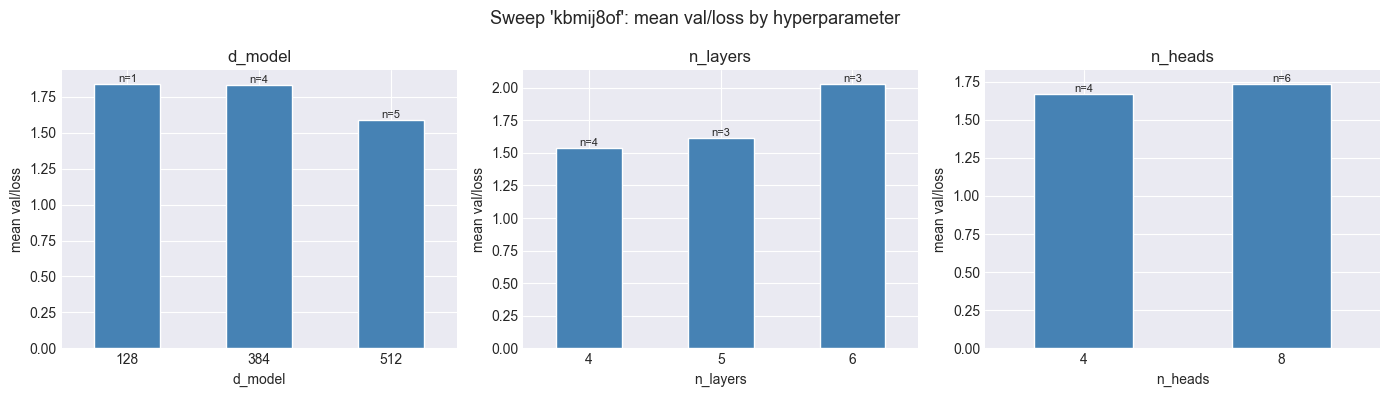

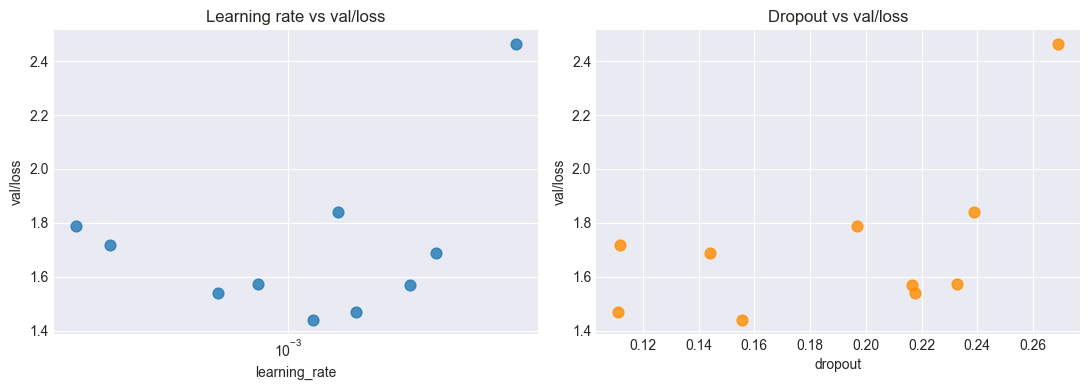

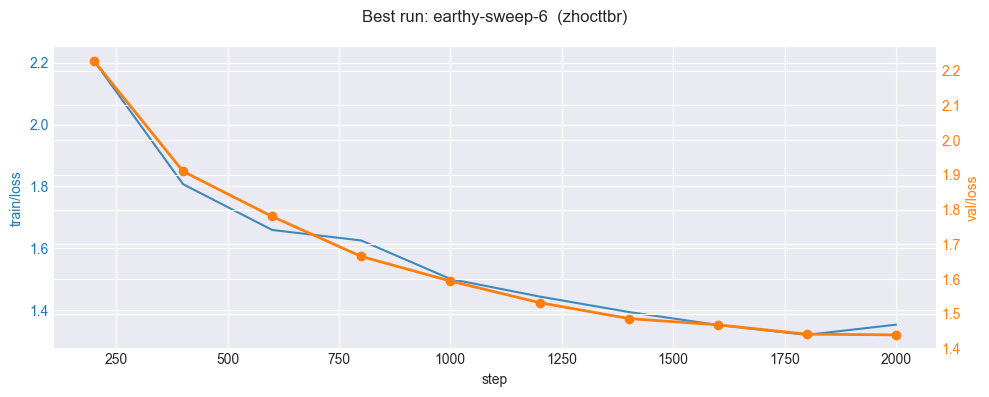

In [12]:
if runs_df.empty:
    print("Nothing to plot; fetch runs first.")
else:
    best = runs_df.iloc[0]

    # Discrete hyperparameter sensitivity: mean validation loss for each setting.
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"Sweep '{sweep_id}': mean {SWEEP_METRIC} by hyperparameter", fontsize=13)

    for ax, param in zip(axes, ["d_model", "n_layers", "n_heads"]):
        summary = runs_df.groupby(param, observed=True)[SWEEP_METRIC].agg(["mean", "count"])
        summary["mean"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
        ax.set_title(param)
        ax.set_xlabel(param)
        ax.set_ylabel(f"mean {SWEEP_METRIC}")
        ax.tick_params(axis="x", rotation=0)
        for i, (_, row) in enumerate(summary.iterrows()):
            ax.text(i, row["mean"], f"n={int(row['count'])}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

    # Continuous hyperparameters: scatter plots for learning rate and dropout.
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(runs_df["learning_rate"], runs_df[SWEEP_METRIC], alpha=0.8, s=60)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("learning_rate")
    axes[0].set_ylabel(SWEEP_METRIC)
    axes[0].set_title("Learning rate vs val/loss")

    axes[1].scatter(runs_df["dropout"], runs_df[SWEEP_METRIC], alpha=0.8, s=60, color="darkorange")
    axes[1].set_xlabel("dropout")
    axes[1].set_ylabel(SWEEP_METRIC)
    axes[1].set_title("Dropout vs val/loss")
    plt.tight_layout()
    plt.show()

    # --- Training curve for the best run ---
    api = wandb.Api()
    best_run = api.run(f"{_sweep_api_path(sweep_id).rsplit('/', 1)[0]}/{best['run_id']}")
    hist = best_run.history(keys=["train/loss", SWEEP_METRIC, "optim/lr"])
    steps = hist["_step"] if "_step" in hist.columns else range(len(hist))

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(steps, hist["train/loss"], label="train/loss", alpha=0.85)
    ax1.set_xlabel("step")
    ax1.set_ylabel("train/loss", color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")

    eval_mask = hist[SWEEP_METRIC].notna()
    ax2 = ax1.twinx()
    ax2.plot(steps[eval_mask], hist.loc[eval_mask, SWEEP_METRIC], "o-", color="C1", label="val/loss", linewidth=2)
    ax2.set_ylabel("val/loss", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")

    fig.suptitle(f"Best run: {best['run_name']}  ({best['run_id']})")
    fig.tight_layout()
    plt.show()

## Notes

- Requires `data/artifacts/` produced by notebook 2.
- Best checkpoint per trial is saved as `data/checkpoints/gpt_sweep_<run_id>.pt`.
- Model artifacts are logged with names like `tinyshakespeare-char-gpt-<run_id>`.
- Full run comparison is also available on your [W&B sweep page](https://wandb.ai).